# CIND820 Big Data Analytics Project
# Machine Learning Models

## Aaron Hosein

### July 28, 2025

The following dataset was retrieved from Kaggle under a public domain license.\
The dataset contains information on new vehicles released during 2024.
The below outlines a Machine Learning model comparison to predict the price of a vehicle given vehicle features.
The three models compared include: linear regression, random forest and XGBoost.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
vehicle_df = pd.read_csv('vehicles_dataset.csv')

# Display the first few rows
vehicle_df.head()

,name,description,make,model,type,year,price,engine,cylinders,fuel,mileage,transmission,trim,body,doors,exterior_color,interior_color,drivetrain
0,2024 Jeep Wagoneer Series II,"\n \n Heated Leather Seats, Nav Sy...",Jeep,Wagoneer,New,2024,74600.0,24V GDI DOHC Twin Turbo,6.0,Gasoline,10.0,8-Speed Automatic,Series II,SUV,4.0,White,Global Black,Four-wheel Drive
1,2024 Jeep Grand Cherokee Laredo,Al West is committed to offering every custome...,Jeep,Grand Cherokee,New,2024,50170.0,OHV,6.0,Gasoline,1.0,8-Speed Automatic,Laredo,SUV,4.0,Metallic,Global Black,Four-wheel Drive
2,2024 GMC Yukon XL Denali,NaN,GMC,Yukon XL,New,2024,96410.0,"6.2L V-8 gasoline direct injection, variable v...",8.0,Gasoline,0.0,Automatic,Denali,SUV,4.0,Summit White,Teak/Light Shale,Four-wheel Drive
3,2023 Dodge Durango Pursuit,White Knuckle Clearcoat 2023 Dodge Durango Pur...,Dodge,Durango,New,2023,46835.0,16V MPFI OHV,8.0,Gasoline,32.0,8-Speed Automatic,Pursuit,SUV,4.0,White Knuckle Clearcoat,Black,All-wheel Drive
4,2024 RAM 3500 Laramie,\n \n 2024 Ram 3500 Laramie Billet...,RAM,3500,New,2024,81663.0,24V DDI OHV Turbo Diesel,6.0,Diesel,10.0,6-Speed Automatic,Laramie,Pickup Truck,4.0,Silver,Black,Four-wheel Drive


C:\Users\aahos\anaconda3\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


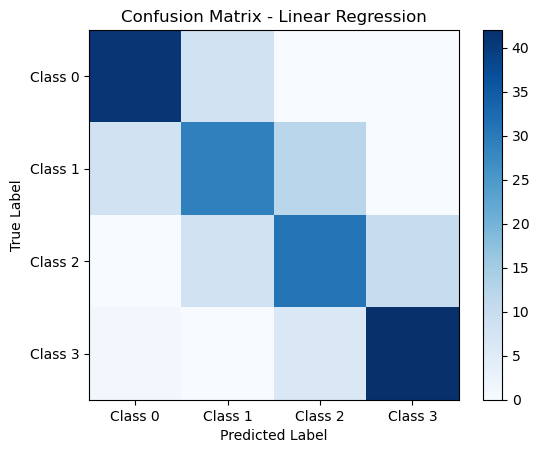

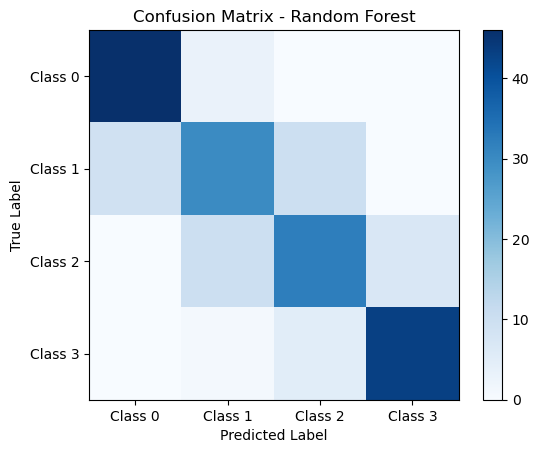

C:\Users\aahos\anaconda3\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\aahos\anaconda3\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\aahos\anaconda3\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\aahos\anaconda3\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
C:\Users\aahos\anaconda3\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


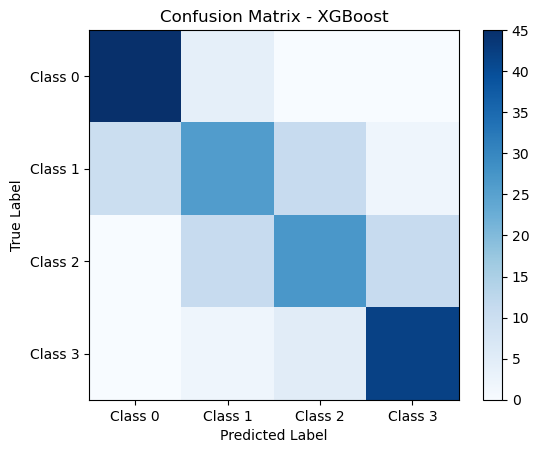

Model: Linear Regression
Train-Test Accuracy: 0.73
Cross-Validation Mean Accuracy: 0.69 (± 0.03)
Confusion Matrix:
[[41  8  0  0]
 [ 8 29 12  0]
 [ 0  8 31 10]
 [ 1  0  6 42]]


Model: Random Forest
Train-Test Accuracy: 0.77
Cross-Validation Mean Accuracy: 0.73 (± 0.04)
Confusion Matrix:
[[46  3  0  0]
 [ 9 30 10  0]
 [ 0 10 32  7]
 [ 0  1  5 43]]


Model: XGBoost
Train-Test Accuracy: 0.71
Cross-Validation Mean Accuracy: 0.71 (± 0.03)
Confusion Matrix:
[[45  4  0  0]
 [10 26 11  2]
 [ 0 11 27 11]
 [ 0  2  5 42]]


Class 0: $0.0 to $36600.0
Class 1: $36600.0 to $47165.0
Class 2: $47165.0 to $58909.0
Class 3: $58909.0 to $195895.0


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt

# Load the dataset
df_clean = pd.read_csv("vehicles_dataset.csv")

# Remove rows with missing values
#df_clean = df_clean.dropna()

#'''
# Fill missing 'description' with a placeholder string
df_clean['description'] = df_clean['description'].fillna('No description provided')

# Drop rows with missing 'price' values — usually critical for analysis
df_clean = df_clean.dropna(subset=['price'])

# Fill missing 'engine' with 'Unknown'
#df['engine'] = df['engine'].fillna('Unknown')
df_clean = df_clean.dropna(subset=['engine'])

# Fill 'cylinders' with median (numeric and often varies by model)
df_clean['cylinders'] = df_clean['cylinders'].fillna(df_clean['cylinders'].median())

# Fill 'fuel' with mode (most common fuel type)
df_clean['fuel'] = df_clean['fuel'].fillna(df_clean['fuel'].mode()[0])

# Fill 'mileage' with median — often skewed, so median is better than mean
df_clean['mileage'] = df_clean['mileage'].fillna(df_clean['mileage'].median())

# Fill 'transmission' with mode (most common transmission type)
df_clean['transmission'] = df_clean['transmission'].fillna(df_clean['transmission'].mode()[0])

# Fill 'trim' with 'Unknown'
df_clean['trim'] = df_clean['trim'].fillna('Unknown')

# Fill 'body' with mode
df_clean['body'] = df_clean['body'].fillna(df_clean['body'].mode()[0])

# Fill 'doors' with mode — generally 2 or 4
df_clean['doors'] = df_clean['doors'].fillna(df_clean['doors'].mode()[0])

# Fill 'exterior_color' and 'interior_color' with 'Unknown'
df_clean['exterior_color'] = df_clean['exterior_color'].fillna('Unknown')
df_clean['interior_color'] = df_clean['interior_color'].fillna('Unknown')
#'''

# Prepare dataframe by dropping redundant or irrevelant features and select target parameter
X = df_clean.drop(['price', 'name', 'description', 'type', 'engine', 'trim'], axis=1)
y = df_clean['price']

# Convert continuous price to categories for classification. pd.qcut to split continuous data into four equal size categories
price_bins = pd.qcut(y, q=4, labels=False)
y = price_bins

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

# One-Hot encoding for categorical variables
preprocessor = ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)],
                                 remainder='passthrough')

# Train-test split data into 80-20 ratios
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define machine learning models for comparison
models = {
    # Linear regression normally for continuous values, but used for classification by round continuous values to categories
    'Linear Regression': LinearRegression(),
    
    # Classification model using 42 as a starting seed
    'Random Forest': RandomForestClassifier(random_state=42),
    
    # Advanced classification model similar to random forest
    # mlogloss selected for multi-class classification
    # Uses 42 as a starting seed for reproducing model
    # 50 estimators to control how complex the model computes
    # max depth of 3 to control over-fitting but also complexity
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_estimators=50, max_depth=3)
}

# Store results for comparison
results = {}

# Cross-validation setup - compare model with multiple subsets of dataset to provide more reliable estimate
# StratifiedKFold specfically ensures each fold is proportional to remove bias
# Split the dataset into 5 folds
# Shuffle the data before splitting the folds
# 42 is random seed for reproducing results
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)

    # Train on test set
    if model_name == 'Linear Regression':
        y_pred_continuous = pipeline.predict(X_test)
        y_pred = np.clip(np.round(y_pred_continuous), 0, 3).astype(int)
    else:
        y_pred = pipeline.predict(X_test)

    # Accuracy and Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    # Cross-validation scoring
    if model_name == 'Linear Regression':
        # For cross-validation, map continuous predictions to class labels
        def cv_scorer(pipe, X, y):
            y_pred_cv = pipe.predict(X)
            y_pred_cv = np.clip(np.round(y_pred_cv), 0, 3).astype(int)
            return accuracy_score(y, y_pred_cv)

        cv_scores = []
        for train_idx, val_idx in cv.split(X, y):
            pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
            pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
            cv_scores.append(cv_scorer(pipe, X.iloc[val_idx], y.iloc[val_idx]))
    else:
        cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')

    results[model_name] = {
        'confusion_matrix': cm,
        'accuracy': acc,
        'cv_mean_accuracy': np.mean(cv_scores),
        'cv_std': np.std(cv_scores)
    }

    # Plot confusion matrix
    plt.figure()
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.colorbar()
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(np.arange(4), [f'Class {i}' for i in range(4)])
    plt.yticks(np.arange(4), [f'Class {i}' for i in range(4)])
    plt.show()

# Display results
for model_name, metrics in results.items():
    print(f"Model: {model_name}")
    print(f"Train-Test Accuracy: {metrics['accuracy']:.2f}")
    print(f"Cross-Validation Mean Accuracy: {metrics['cv_mean_accuracy']:.2f} (± {metrics['cv_std']:.2f})")
    print("Confusion Matrix:")
    print(metrics['confusion_matrix'])
    print("\n")

# Calculate the bin edges using pd.qcut
bins = pd.qcut(df_clean['price'], q=4, retbins=True)[1]
price_ranges = [(round(bins[i], 2), round(bins[i+1], 2)) for i in range(len(bins) - 1)]

for idx, (low, high) in enumerate(price_ranges):
    print(f"Class {idx}: ${low} to ${high}")


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv("vehicles_dataset.csv")

# Drop rows with any missing values
#df_clean = df.dropna()

#'''
# Fill missing 'description' with a placeholder string
df_clean['description'] = df_clean['description'].fillna('No description provided')

# Drop rows with missing 'price' values — usually critical for analysis
df_clean = df_clean.dropna(subset=['price'])

# Fill missing 'engine' with 'Unknown'
#df['engine'] = df['engine'].fillna('Unknown')
df_clean = df_clean.dropna(subset=['engine'])

# Fill 'cylinders' with median (numeric and often varies by model)
df_clean['cylinders'] = df_clean['cylinders'].fillna(df_clean['cylinders'].median())

# Fill 'fuel' with mode (most common fuel type)
df_clean['fuel'] = df_clean['fuel'].fillna(df_clean['fuel'].mode()[0])

# Fill 'mileage' with median — often skewed, so median is better than mean
df_clean['mileage'] = df_clean['mileage'].fillna(df_clean['mileage'].median())

# Fill 'transmission' with mode (most common transmission type)
df_clean['transmission'] = df_clean['transmission'].fillna(df_clean['transmission'].mode()[0])

# Fill 'trim' with 'Unknown'
df_clean['trim'] = df_clean['trim'].fillna('Unknown')

# Fill 'body' with mode
df_clean['body'] = df_clean['body'].fillna(df_clean['body'].mode()[0])

# Fill 'doors' with mode — generally 2 or 4
df_clean['doors'] = df_clean['doors'].fillna(df_clean['doors'].mode()[0])

# Fill 'exterior_color' and 'interior_color' with 'Unknown'
df_clean['exterior_color'] = df_clean['exterior_color'].fillna('Unknown')
df_clean['interior_color'] = df_clean['interior_color'].fillna('Unknown')
#'''

# Separate features and target
X = df_clean.drop(columns=['price', 'name', 'description', 'type', 'engine', 'trim'])  # Drop target and freeform text fields
y = df_clean["price"]

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Preprocessing of data
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ],
    remainder="passthrough"  # Leave numerical columns unchanged
)

# Define the Random Forest model
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42, n_estimators=100))
])

# Split the data into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"R² Score: {r2:.2f}")

Mean Squared Error (MSE): 65,404,862.77
R² Score: 0.80
